
# Milestone 5 — Merging the Data, Storing in a Database, and Visualizing the Data

**Student:** Adjovi Lembila Akpaki  
**Project Topic:** Examining the Impact of Economic Factors on Health Outcomes  
**Course Deliverable:** Milestone 5

## Purpose
In this notebook, I merge my three cleaned datasets into one project database, join them into one analysis-ready dataset, create five clearly labeled visualizations, print a version of the merged data, and provide a written reflection on what I learned and the ethical implications of my work.

## Milestone 5 Checklist
In this notebook, I:
1. import the libraries I need,
2. load and clean the three project datasets,
3. store each dataset in SQLite as an individual table,
4. join the tables together with SQL,
5. print a readable version of the merged dataset,
6. create five visualizations,
7. include at least two visuals that use data from more than one source,
8. write a 250–500 word summary, and
9. answer the required ethical implications questions.


In [14]:
%pip install lxml html5lib beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [38]:

# Core imports for data work, database storage, and visualization
import io
import re
import json
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)



## Step 1 — Define helper functions and file locations
In this step, I define the reusable functions that help me standardize names, fetch data, and make the joins more consistent. I also define my local file paths so the notebook can use a local file first and then fall back to the web if needed.


In [40]:
# Local project files
LIFE_CANDIDATES = [
    Path("Life Expectancy Data (1).csv"),
    Path("Life Expectancy Data.csv"),
    Path("/mnt/data/Life Expectancy Data (1).csv"),
    Path("/mnt/data/Life Expectancy Data.csv"),
]
DB_PATH = Path("milestone5_health_econ.db")

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"
REST_URL = "https://restcountries.com/v3.1/all?fields=name,cca3,population,area,region,subregion,capital,languages,currencies"
LIFE_FALLBACK_URL = "https://raw.githubusercontent.com/Sudhir878786/Life-Expectancy-WHO/master/Life%20Expectancy%20Data.csv"

def to_snake(col: str) -> str:
    """Convert a column name into snake_case."""
    col = str(col).strip().lower()
    col = re.sub(r"\[.*?\]", "", col)
    col = re.sub(r"[%()/\-]", " ", col)
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def standardize_country_name(name: str) -> str:
    """Apply lightweight country name harmonization for joining across sources."""
    if pd.isna(name):
        return np.nan
    s = str(name).strip()
    s = re.sub(r"\[.*?\]", "", s).strip()
    replacements = {
        "United States Of America": "United States",
        "United States Of America (The)": "United States",
        "Usa": "United States",
        "Uk": "United Kingdom",
        "Russian Federation": "Russia",
        "Viet Nam": "Vietnam",
        "Iran (Islamic Republic Of)": "Iran",
        "Iran, Islamic Republic Of": "Iran",
        "Republic Of Korea": "South Korea",
        "Korea, Republic Of": "South Korea",
        "Democratic People's Republic Of Korea": "North Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Syrian Arab Republic": "Syria",
        "Venezuela (Bolivarian Republic Of)": "Venezuela",
        "Lao People's Democratic Republic": "Laos",
        "Brunei Darussalam": "Brunei",
        "United Republic Of Tanzania": "Tanzania",
        "Bolivia (Plurinational State Of)": "Bolivia",
        "Moldova, Republic Of": "Moldova",
        "Republic Of Moldova": "Moldova",
        "Czechia": "Czech Republic",
        "Türkiye": "Turkey",
        "The Bahamas": "Bahamas",
        "The Gambia": "Gambia",
        "Côte D'Ivoire": "Cote D'Ivoire",
        "Curaçao": "Curacao",
        "Réunion": "Reunion",
    }
    s = s.title()
    return replacements.get(s, s)

def find_or_download_life_file():
    """Find the life expectancy CSV locally; if missing, try downloading a fallback copy."""
    for path in LIFE_CANDIDATES:
        if path.exists():
            print(f"I found the life expectancy file at: {path}")
            return path

    print("I could not find the life expectancy CSV locally, so I am trying a fallback download...")
    try:
        import requests
        response = requests.get(LIFE_FALLBACK_URL, timeout=30)
        response.raise_for_status()
        save_path = Path("Life Expectancy Data.csv")
        save_path.write_bytes(response.content)
        print(f"I downloaded the life expectancy CSV to: {save_path}")
        return save_path
    except Exception as e:
        raise FileNotFoundError(
            "I could not find the life expectancy CSV locally, and the fallback download did not work. "
            "Please upload 'Life Expectancy Data (1).csv' or place it in the same folder as this notebook."
        ) from e

def fetch_html_tables(url: str):
    """Download an HTML page and parse all tables from it."""
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        html = requests.get(url, headers=headers, timeout=30).text
    except Exception:
        from urllib.request import Request, urlopen
        req = Request(url, headers=headers)
        with urlopen(req, timeout=30) as r:
            html = r.read().decode("utf-8", errors="replace")
    return pd.read_html(io.StringIO(html))

def fetch_json(url: str):
    """Fetch JSON data from an API endpoint."""
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()



## Step 2 — Load and clean Dataset 1: Life Expectancy flat file
In this step, I load the life expectancy CSV from my flat-file source and apply the same style of cleaning I used in my earlier milestone: standardizing headers, fixing text values, converting numeric fields, removing duplicates, and preparing consistent join fields.


In [41]:
life_file = find_or_download_life_file()

life_raw = pd.read_csv(life_file)
print("Raw life expectancy shape:", life_raw.shape)
display(life_raw.head())


I found the life expectancy file at: Life Expectancy Data.csv
Raw life expectancy shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [42]:

life_df = life_raw.copy()
life_df.columns = [to_snake(c) for c in life_df.columns]

# Standardize important text columns
if "country" in life_df.columns:
    life_df["country"] = life_df["country"].astype(str).str.strip().apply(standardize_country_name)
if "status" in life_df.columns:
    life_df["status"] = life_df["status"].astype(str).str.strip().str.title()

# Convert year and other numeric columns
if "year" in life_df.columns:
    life_df["year"] = pd.to_numeric(life_df["year"], errors="coerce").astype("Int64")

for col in life_df.columns:
    if col not in ["country", "status"]:
        life_df[col] = pd.to_numeric(life_df[col], errors="coerce")

# Remove exact duplicates and duplicate country-year pairs
life_df = life_df.drop_duplicates()
if set(["country", "year"]).issubset(life_df.columns):
    life_df = (
        life_df
        .sort_values(["country", "year"])
        .drop_duplicates(subset=["country", "year"], keep="last")
    )

# Remove impossible negative values for fields that should not be negative
nonnegative_candidates = [
    c for c in life_df.columns
    if c not in ["country", "status"]
]
for col in nonnegative_candidates:
    if pd.api.types.is_numeric_dtype(life_df[col]):
        life_df.loc[life_df[col] < 0, col] = np.nan

# Keep a project-friendly subset of columns most useful for merging and plotting
preferred_life_cols = [
    "country", "year", "status", "life_expectancy", "adult_mortality", "infant_deaths",
    "alcohol", "percentage_expenditure", "hepatitis_b", "measles", "bmi", "under_five_deaths",
    "polio", "total_expenditure", "diphtheria", "hiv_aids", "gdp", "population",
    "thinness_1_19_years", "thinness_5_9_years", "income_composition_of_resources", "schooling"
]
life_cols = [c for c in preferred_life_cols if c in life_df.columns]
life_df = life_df[life_cols].copy()

# Add ISO3 mapping helper using REST countries later if possible
print("Cleaned life expectancy shape:", life_df.shape)
display(life_df.head())


Cleaned life expectancy shape: (2938, 22)


,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
15,Afghanistan,2000,Developing,54.8,321.0,88.0,0.01,10.424960,62.0,6532.0,12.2,122.0,24.0,8.20,24.0,0.1,114.560000,293756.0,2.3,2.5,0.338,5.5
14,Afghanistan,2001,Developing,55.3,316.0,88.0,0.01,10.574728,63.0,8762.0,12.6,122.0,35.0,7.80,33.0,0.1,117.496980,2966463.0,2.1,2.4,0.340,5.9
13,Afghanistan,2002,Developing,56.2,3.0,88.0,0.01,16.887351,64.0,2486.0,13.0,122.0,36.0,7.76,36.0,0.1,187.845950,21979923.0,19.9,2.2,0.341,6.2
12,Afghanistan,2003,Developing,56.7,295.0,87.0,0.01,11.089053,65.0,798.0,13.4,122.0,41.0,8.82,41.0,0.1,198.728544,2364851.0,19.7,19.9,0.373,6.5
11,Afghanistan,2004,Developing,57.0,293.0,87.0,0.02,15.296066,67.0,466.0,13.8,120.0,5.0,8.79,5.0,0.1,219.141353,24118979.0,19.5,19.7,0.381,6.8



## Step 3 — Load and clean Dataset 2: Wikipedia population table
In this step, I pull the population table directly from Wikipedia, clean the headers, standardize country names, convert numeric columns, remove duplicates, and keep the fields I need for merging and visualizing.


In [43]:

wiki_tables = fetch_html_tables(WIKI_URL)
print(f"Number of tables read from Wikipedia: {len(wiki_tables)}")

# Select the main population table by looking for a country/location column and a population column
population_raw = None
for tbl in wiki_tables:
    test = tbl.copy()
    test.columns = [to_snake(c) for c in test.columns]
    cols = set(test.columns)
    if ("location" in cols or "country" in cols) and "population" in cols:
        population_raw = test
        break

if population_raw is None:
    raise ValueError("I could not identify the main Wikipedia population table.")

print("Raw Wikipedia population shape:", population_raw.shape)
display(population_raw.head())


Number of tables read from Wikipedia: 3
Raw Wikipedia population shape: (240, 6)


,location,population,of_world,date,source_official_or_from_the_united_nations,notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.1%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.2%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,284438782,3.5%,30 Jun 2025,National annual projection[7],NaN


In [44]:

population_df = population_raw.copy()
population_df.columns = [to_snake(c) for c in population_df.columns]

# Create a consistent country field
country_source_col = "location" if "location" in population_df.columns else "country"
population_df["country"] = (
    population_df[country_source_col]
    .astype(str)
    .str.replace(r"\[.*?\]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .apply(standardize_country_name)
)

# Convert numeric/text fields
if "population" in population_df.columns:
    population_df["population"] = (
        population_df["population"]
        .astype(str)
        .str.replace(r"\[.*?\]", "", regex=True)
        .str.replace(",", "", regex=False)
        .str.extract(r"([0-9]+(?:\.[0-9]+)?)", expand=False)
    )
    population_df["population"] = pd.to_numeric(population_df["population"], errors="coerce")

if "of_world" in population_df.columns:
    population_df["pct_of_world"] = (
        population_df["of_world"].astype(str).str.replace("%", "", regex=False)
    )
    population_df["pct_of_world"] = pd.to_numeric(population_df["pct_of_world"], errors="coerce")
elif "pct_of_world" in population_df.columns:
    population_df["pct_of_world"] = pd.to_numeric(population_df["pct_of_world"], errors="coerce")

if "date" in population_df.columns:
    population_df["as_of_date"] = pd.to_datetime(population_df["date"], errors="coerce")

if "rank" in population_df.columns:
    population_df["rank"] = pd.to_numeric(population_df["rank"], errors="coerce")

population_df["population_millions"] = (population_df["population"] / 1_000_000).round(3)

# Remove missing/duplicate country rows and keep the largest population if duplicates remain
population_df = population_df.dropna(subset=["country", "population"])
population_df = (
    population_df.sort_values(["country", "population"], ascending=[True, False])
    .drop_duplicates(subset=["country"], keep="first")
)

preferred_population_cols = [
    "rank", "country", "population", "population_millions", "pct_of_world", "as_of_date"
]
population_cols = [c for c in preferred_population_cols if c in population_df.columns]
population_df = population_df[population_cols].copy()

print("Cleaned Wikipedia population shape:", population_df.shape)
display(population_df.head())


Cleaned Wikipedia population shape: (240, 5)


,country,population,population_millions,pct_of_world,as_of_date
185,Abkhazia,244236,0.244,0.0030,2022-01-01
36,Afghanistan,43844000,43.844,0.5000,2025-07-01
145,Albania,2363314,2.363,0.0300,2025-01-01
32,Algeria,47400000,47.400,0.6000,2025-01-01
212,American Samoa (Us),49710,0.050,0.0006,2020-04-01



## Step 4 — Load and clean Dataset 3: REST Countries API
In this step, I call the REST Countries API, normalize the nested JSON into a rectangular table, clean the text and numeric fields, and keep the country-level attributes I need for my merged analysis.


In [45]:

api_data = fetch_json(REST_URL)
api_raw = pd.json_normalize(api_data)
print("Raw API shape:", api_raw.shape)
display(api_raw.head())


Raw API shape: (250, 792)


,cca3,capital,region,subregion,area,population,name.common,name.official,name.nativeName.bwg.official,name.nativeName.bwg.common,name.nativeName.eng.official,name.nativeName.eng.common,name.nativeName.kck.official,name.nativeName.kck.common,name.nativeName.khi.official,name.nativeName.khi.common,name.nativeName.ndc.official,name.nativeName.ndc.common,name.nativeName.nde.official,name.nativeName.nde.common,name.nativeName.nya.official,name.nativeName.nya.common,name.nativeName.sna.official,name.nativeName.sna.common,name.nativeName.sot.official,name.nativeName.sot.common,name.nativeName.toi.official,name.nativeName.toi.common,name.nativeName.tsn.official,name.nativeName.tsn.common,name.nativeName.tso.official,name.nativeName.tso.common,name.nativeName.ven.official,name.nativeName.ven.common,name.nativeName.xho.official,name.nativeName.xho.common,name.nativeName.zib.official,name.nativeName.zib.common,currencies.ZWL.name,currencies.ZWL.symbol,languages.bwg,languages.eng,languages.kck,languages.khi,languages.ndc,languages.nde,languages.nya,languages.sna,languages.sot,languages.toi,...,name.nativeName.som.official,name.nativeName.som.common,currencies.SOS.name,currencies.SOS.symbol,languages.som,name.nativeName.jpn.official,name.nativeName.jpn.common,currencies.JPY.name,currencies.JPY.symbol,languages.jpn,currencies.MOP.name,currencies.MOP.symbol,currencies.SDG.name,currencies.SDG.symbol,currencies.SZL.name,currencies.SZL.symbol,name.nativeName.ben.official,name.nativeName.ben.common,currencies.BDT.name,currencies.BDT.symbol,languages.ben,name.nativeName.sag.official,name.nativeName.sag.common,languages.sag,currencies.CAD.name,currencies.CAD.symbol,currencies.CVE.name,currencies.CVE.symbol,name.nativeName.urd.official,name.nativeName.urd.common,currencies.PKR.name,currencies.PKR.symbol,languages.urd,name.nativeName.nep.official,name.nativeName.nep.common,currencies.NPR.name,currencies.NPR.symbol,languages.nep,name.nativeName.bos.official,name.nativeName.bos.common,currencies.BAM.name,currencies.BAM.symbol,languages.bos,currencies.SSP.name,currencies.SSP.symbol,name.nativeName.pov.official,name.nativeName.pov.common,languages.pov,currencies.LBP.name,currencies.LBP.symbol
0,ZWE,[Harare],Africa,Southern Africa,390757.0,17073087,Zimbabwe,Republic of Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Republic of Zimbabwe,Zimbabwe,Zimbabwean dollar,$,Chibarwe,English,Kalanga,Khoisan,Ndau,Northern Ndebele,Chewa,Shona,Sotho,Tonga,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KIR,[South Tarawa],Oceania,Micronesia,811.0,120740,Kiribati,Independent and Sovereign Republic of Kiribati,NaN,NaN,Independent and Sovereign Republic of Kiribati,Kiribati,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GHA,[Accra],Africa,Western Africa,238533.0,33742380,Ghana,Republic of Ghana,NaN,NaN,Republic of Ghana,Ghana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,English,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [46]:

def first_item(x):
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return np.nan


def dict_keys_joined(d):
    if isinstance(d, dict) and len(d) > 0:
        return ", ".join(sorted(d.keys()))
    return np.nan


def dict_len(d):
    if isinstance(d, dict):
        return len(d)
    return np.nan

api_df = pd.DataFrame({
    "country": api_raw.get("name.common", pd.Series(dtype=object)).apply(standardize_country_name),
    "iso3": api_raw.get("cca3", pd.Series(dtype=object)).astype(str).str.strip(),
    "region": api_raw.get("region", pd.Series(dtype=object)).astype(str).str.strip(),
    "subregion": api_raw.get("subregion", pd.Series(dtype=object)).astype(str).str.strip(),
    "capital": api_raw.get("capital", pd.Series(dtype=object)).apply(first_item),
    "api_population": pd.to_numeric(api_raw.get("population", pd.Series(dtype=float)), errors="coerce"),
    "area_km2": pd.to_numeric(api_raw.get("area", pd.Series(dtype=float)), errors="coerce"),
    "language_count": api_raw.get("languages", pd.Series(dtype=object)).apply(dict_len),
    "currency_codes": api_raw.get("currencies", pd.Series(dtype=object)).apply(dict_keys_joined),
})

api_df["population_density"] = api_df["api_population"] / api_df["area_km2"]
api_df["log_population"] = np.where(api_df["api_population"] > 0, np.log10(api_df["api_population"]), np.nan)
api_df["log_area_km2"] = np.where(api_df["area_km2"] > 0, np.log10(api_df["area_km2"]), np.nan)

# Normalize text and remove unusable records
api_df["country"] = api_df["country"].astype(str).str.strip().apply(standardize_country_name)
api_df["region"] = api_df["region"].replace({"": np.nan}).fillna("Unknown")
api_df["subregion"] = api_df["subregion"].replace({"": np.nan}).fillna("Unknown")
api_df = api_df.dropna(subset=["country", "iso3", "api_population"])
api_df = api_df.drop_duplicates(subset=["iso3"], keep="first")

print("Cleaned API shape:", api_df.shape)
display(api_df.head())


Cleaned API shape: (250, 12)


,country,iso3,region,subregion,capital,api_population,area_km2,language_count,currency_codes,population_density,log_population,log_area_km2
0,Zimbabwe,ZWE,Africa,Southern Africa,Harare,17073087,390757.0,NaN,NaN,43.692338,7.232312,5.591907
1,Kiribati,KIR,Oceania,Micronesia,South Tarawa,120740,811.0,NaN,NaN,148.877928,5.081851,2.909021
2,Ghana,GHA,Africa,Western Africa,Accra,33742380,238533.0,NaN,NaN,141.457911,7.528176,5.377548
3,North Korea,PRK,Asia,Eastern Asia,Pyongyang,25950000,120538.0,NaN,NaN,215.284806,7.414137,5.081124
4,Spain,ESP,Europe,Southern Europe,Madrid,49315949,505992.0,NaN,NaN,97.463891,7.692987,5.704144



## Step 5 — Create an ISO3 bridge so the life expectancy data joins more cleanly
The life expectancy dataset does not always include ISO3 codes, so in this step I create a country-to-ISO3 bridge from the API data and attach it to the life expectancy data. This improves consistency when I later store and join the tables in SQL.


In [47]:

country_iso_bridge = api_df[["country", "iso3", "region", "subregion"]].drop_duplicates()
life_df = life_df.merge(country_iso_bridge[["country", "iso3"]], on="country", how="left")

# Reorder for readability
life_front = [c for c in ["country", "iso3", "year", "status", "life_expectancy", "gdp", "population"] if c in life_df.columns]
life_rest = [c for c in life_df.columns if c not in life_front]
life_df = life_df[life_front + life_rest]

print("Life expectancy records with ISO3 attached:")
display(life_df.head())
print("Rows with missing ISO3 after the bridge:", life_df["iso3"].isna().sum())


Life expectancy records with ISO3 attached:


,country,iso3,year,status,life_expectancy,gdp,population,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,AFG,2000,Developing,54.8,114.560000,293756.0,321.0,88.0,0.01,10.424960,62.0,6532.0,12.2,122.0,24.0,8.20,24.0,0.1,2.3,2.5,0.338,5.5
1,Afghanistan,AFG,2001,Developing,55.3,117.496980,2966463.0,316.0,88.0,0.01,10.574728,63.0,8762.0,12.6,122.0,35.0,7.80,33.0,0.1,2.1,2.4,0.340,5.9
2,Afghanistan,AFG,2002,Developing,56.2,187.845950,21979923.0,3.0,88.0,0.01,16.887351,64.0,2486.0,13.0,122.0,36.0,7.76,36.0,0.1,19.9,2.2,0.341,6.2
3,Afghanistan,AFG,2003,Developing,56.7,198.728544,2364851.0,295.0,87.0,0.01,11.089053,65.0,798.0,13.4,122.0,41.0,8.82,41.0,0.1,19.7,19.9,0.373,6.5
4,Afghanistan,AFG,2004,Developing,57.0,219.141353,24118979.0,293.0,87.0,0.02,15.296066,67.0,466.0,13.8,120.0,5.0,8.79,5.0,0.1,19.5,19.7,0.381,6.8


Rows with missing ISO3 after the bridge: 176



## Step 6 — Store each dataset as its own SQLite table
In this step, I create a SQLite database and write each cleaned dataset into its own table. This satisfies the database storage requirement before joining the tables together.


In [48]:
import sqlite3

# Close any old connection first if one already exists
try:
    conn.close()
except:
    pass

DB_PATH = "milestone5_health_econ.db"

# Open a fresh connection
conn = sqlite3.connect(DB_PATH)

# Write each cleaned dataset into SQLite
life_df.to_sql("life_expectancy", conn, if_exists="replace", index=False)
population_df.to_sql("wikipedia_population", conn, if_exists="replace", index=False)
api_df.to_sql("rest_countries", conn, if_exists="replace", index=False)

# Confirm the tables were created
created_tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn
)

print("Tables written to SQLite:")
display(created_tables)

Tables written to SQLite:


,name
0,life_expectancy
1,rest_countries
2,wikipedia_population



## Step 7 — Join the tables together with SQL into one merged dataset
In this step, I use SQL joins to merge the three sources into one final dataset. The life expectancy table gives me year-level health and economic values. The Wikipedia table adds country-level population context. The REST Countries API adds ISO3, region, subregion, capital, and other country metadata.


In [49]:
merge_query = """
SELECT
    l.country,
    l.iso3,
    l.year,
    l.status,
    l.life_expectancy,
    l.adult_mortality,
    l.infant_deaths,
    l.alcohol,
    l.percentage_expenditure,
    l.hepatitis_b,
    l.measles,
    l.bmi,
    l.under_five_deaths,
    l.polio,
    l.total_expenditure,
    l.diphtheria,
    l.hiv_aids,
    l.gdp,
    l.population AS life_population,
    l.thinness_1_19_years,
    l.thinness_5_9_years,
    l.income_composition_of_resources,
    l.schooling,
    w.population AS wikipedia_population,
    w.population_millions,
    w.pct_of_world,
    w.as_of_date,
    r.region,
    r.subregion,
    r.capital,
    r.api_population,
    r.area_km2,
    r.population_density,
    r.language_count,
    r.currency_codes
FROM life_expectancy AS l
LEFT JOIN wikipedia_population AS w
    ON l.country = w.country
LEFT JOIN rest_countries AS r
    ON l.iso3 = r.iso3
"""

merged_df = pd.read_sql_query(merge_query, conn)
print("Merged dataset shape:", merged_df.shape)
display(merged_df.head())

Merged dataset shape: (2938, 35)


,country,iso3,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,life_population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling,wikipedia_population,population_millions,pct_of_world,as_of_date,region,subregion,capital,api_population,area_km2,population_density,language_count,currency_codes
0,Afghanistan,AFG,2000,Developing,54.8,321.0,88.0,0.01,10.424960,62.0,6532.0,12.2,122.0,24.0,8.20,24.0,0.1,114.560000,293756.0,2.3,2.5,0.338,5.5,43844000.0,43.844,0.5,2025-07-01 00:00:00,Asia,Southern Asia,Kabul,43844000.0,652230.0,67.221686,None,None
1,Afghanistan,AFG,2001,Developing,55.3,316.0,88.0,0.01,10.574728,63.0,8762.0,12.6,122.0,35.0,7.80,33.0,0.1,117.496980,2966463.0,2.1,2.4,0.340,5.9,43844000.0,43.844,0.5,2025-07-01 00:00:00,Asia,Southern Asia,Kabul,43844000.0,652230.0,67.221686,None,None
2,Afghanistan,AFG,2002,Developing,56.2,3.0,88.0,0.01,16.887351,64.0,2486.0,13.0,122.0,36.0,7.76,36.0,0.1,187.845950,21979923.0,19.9,2.2,0.341,6.2,43844000.0,43.844,0.5,2025-07-01 00:00:00,Asia,Southern Asia,Kabul,43844000.0,652230.0,67.221686,None,None
3,Afghanistan,AFG,2003,Developing,56.7,295.0,87.0,0.01,11.089053,65.0,798.0,13.4,122.0,41.0,8.82,41.0,0.1,198.728544,2364851.0,19.7,19.9,0.373,6.5,43844000.0,43.844,0.5,2025-07-01 00:00:00,Asia,Southern Asia,Kabul,43844000.0,652230.0,67.221686,None,None
4,Afghanistan,AFG,2004,Developing,57.0,293.0,87.0,0.02,15.296066,67.0,466.0,13.8,120.0,5.0,8.79,5.0,0.1,219.141353,24118979.0,19.5,19.7,0.381,6.8,43844000.0,43.844,0.5,2025-07-01 00:00:00,Asia,Southern Asia,Kabul,43844000.0,652230.0,67.221686,None,None



## Step 8 — Basic quality checks on the merged dataset
In this step, I review missingness, duplicates, and data types in the merged dataset so I can document that the final dataset is analysis-ready.


In [50]:
print("Merged data info:")
merged_df.info()

print()
print("Duplicate country-year rows:", merged_df.duplicated(subset=["country", "year"]).sum())

missing_summary = (
    merged_df.isna().mean().sort_values(ascending=False).mul(100).round(2).to_frame("missing_%")
)

print()
print("Top missingness rates in the merged data:")
display(missing_summary.head(15))

Merged data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2938 non-null   object 
 1   iso3                             2762 non-null   object 
 2   year                             2938 non-null   int64  
 3   status                           2938 non-null   object 
 4   life_expectancy                  2928 non-null   float64
 5   adult_mortality                  2928 non-null   float64
 6   infant_deaths                    2938 non-null   float64
 7   alcohol                          2744 non-null   float64
 8   percentage_expenditure           2938 non-null   float64
 9   hepatitis_b                      2385 non-null   float64
 10  measles                          2938 non-null   float64
 11  bmi                              2904 non-null   float64
 12  un

,missing_%
language_count,100.00
currency_codes,100.00
life_population,22.19
hepatitis_b,18.82
gdp,15.25
as_of_date,8.30
total_expenditure,7.69
alcohol,6.60
api_population,5.99
iso3,5.99



## Step 9 — Create a readable analysis dataset for plotting
For plotting, I create a compact version of the merged data that keeps the key variables needed for the milestone. I also drop rows that are missing the most important fields for the specific plots.


In [51]:

analysis_cols = [
    "country", "iso3", "year", "status", "region", "subregion", "capital",
    "life_expectancy", "gdp", "life_population", "wikipedia_population", "population_millions",
    "pct_of_world", "area_km2", "population_density", "language_count", "schooling",
    "adult_mortality", "hiv_aids", "income_composition_of_resources"
]
analysis_cols = [c for c in analysis_cols if c in merged_df.columns]
analysis_df = merged_df[analysis_cols].copy()

# Make sure key fields are numeric
for col in [
    "life_expectancy", "gdp", "life_population", "wikipedia_population", "population_millions",
    "pct_of_world", "area_km2", "population_density", "language_count", "schooling",
    "adult_mortality", "hiv_aids", "income_composition_of_resources", "year"
]:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

print("Analysis dataset shape:", analysis_df.shape)
display(analysis_df.head(10))


Analysis dataset shape: (2938, 20)


,country,iso3,year,status,region,subregion,capital,life_expectancy,gdp,life_population,wikipedia_population,population_millions,pct_of_world,area_km2,population_density,language_count,schooling,adult_mortality,hiv_aids,income_composition_of_resources
0,Afghanistan,AFG,2000,Developing,Asia,Southern Asia,Kabul,54.8,114.560000,293756.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,5.5,321.0,0.1,0.338
1,Afghanistan,AFG,2001,Developing,Asia,Southern Asia,Kabul,55.3,117.496980,2966463.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,5.9,316.0,0.1,0.340
2,Afghanistan,AFG,2002,Developing,Asia,Southern Asia,Kabul,56.2,187.845950,21979923.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,6.2,3.0,0.1,0.341
3,Afghanistan,AFG,2003,Developing,Asia,Southern Asia,Kabul,56.7,198.728544,2364851.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,6.5,295.0,0.1,0.373
4,Afghanistan,AFG,2004,Developing,Asia,Southern Asia,Kabul,57.0,219.141353,24118979.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,6.8,293.0,0.1,0.381
5,Afghanistan,AFG,2005,Developing,Asia,Southern Asia,Kabul,57.3,25.294130,257798.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,7.9,291.0,0.1,0.396
6,Afghanistan,AFG,2006,Developing,Asia,Southern Asia,Kabul,57.3,272.563770,2589345.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,8.1,295.0,0.1,0.405
7,Afghanistan,AFG,2007,Developing,Asia,Southern Asia,Kabul,57.5,369.835796,26616792.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,8.4,295.0,0.1,0.415
8,Afghanistan,AFG,2008,Developing,Asia,Southern Asia,Kabul,58.1,373.361116,2729431.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,8.7,287.0,0.1,0.433
9,Afghanistan,AFG,2009,Developing,Asia,Southern Asia,Kabul,58.6,445.893298,284331.0,43844000.0,43.844,0.5,652230.0,67.221686,NaN,8.9,281.0,0.1,0.434



## Step 10 — Visualization 1: Average life expectancy over time
This first visualization uses the life expectancy table and shows how average life expectancy changes by year across the available records.


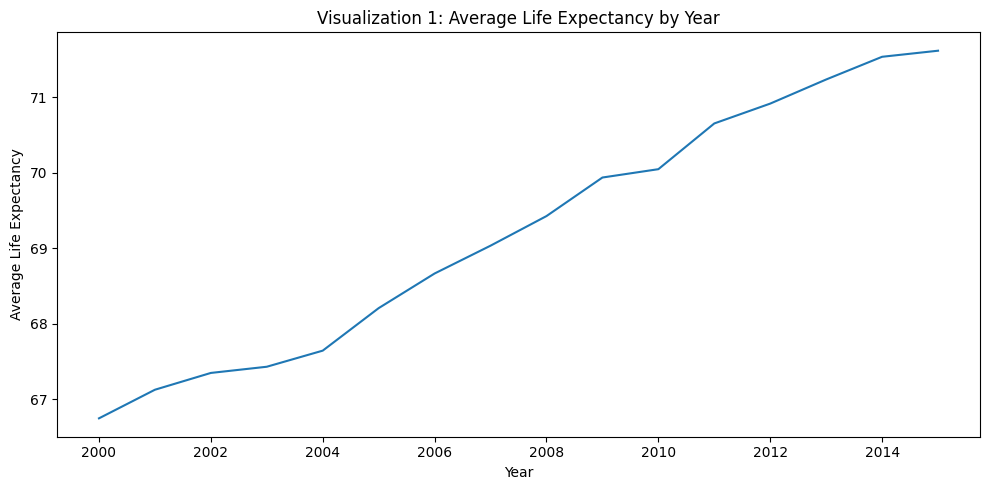

In [52]:

viz1 = (
    analysis_df.dropna(subset=["year", "life_expectancy"])
    .groupby("year", as_index=False)["life_expectancy"].mean()
    .sort_values("year")
)

plt.figure(figsize=(10, 5))
plt.plot(viz1["year"], viz1["life_expectancy"])
plt.title("Visualization 1: Average Life Expectancy by Year")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.tight_layout()
plt.show()



## Step 11 — Visualization 2: GDP vs. life expectancy by region
This second visualization uses data from more than one source because it combines the life expectancy dataset with region data from the REST Countries API after the SQL join.


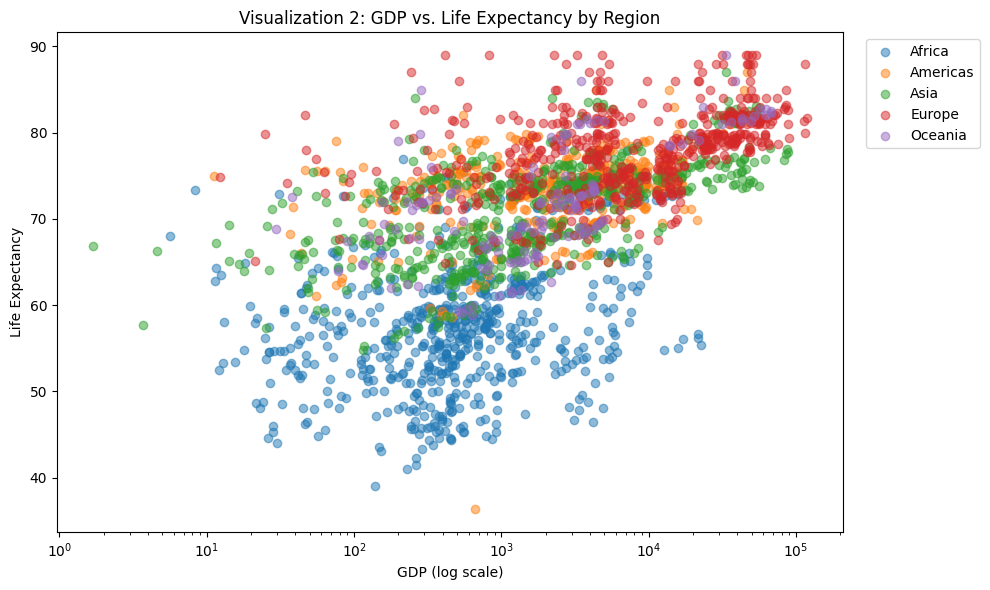

In [53]:

viz2 = analysis_df.dropna(subset=["gdp", "life_expectancy", "region"]).copy()
viz2 = viz2[viz2["gdp"] > 0]

plt.figure(figsize=(10, 6))
for region_name, subset in viz2.groupby("region"):
    plt.scatter(subset["gdp"], subset["life_expectancy"], alpha=0.5, label=region_name)
plt.xscale("log")
plt.title("Visualization 2: GDP vs. Life Expectancy by Region")
plt.xlabel("GDP (log scale)")
plt.ylabel("Life Expectancy")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



## Step 12 — Visualization 3: Average life expectancy by region
This third visualization also uses data from multiple sources because region comes from the API while life expectancy comes from the life expectancy dataset.


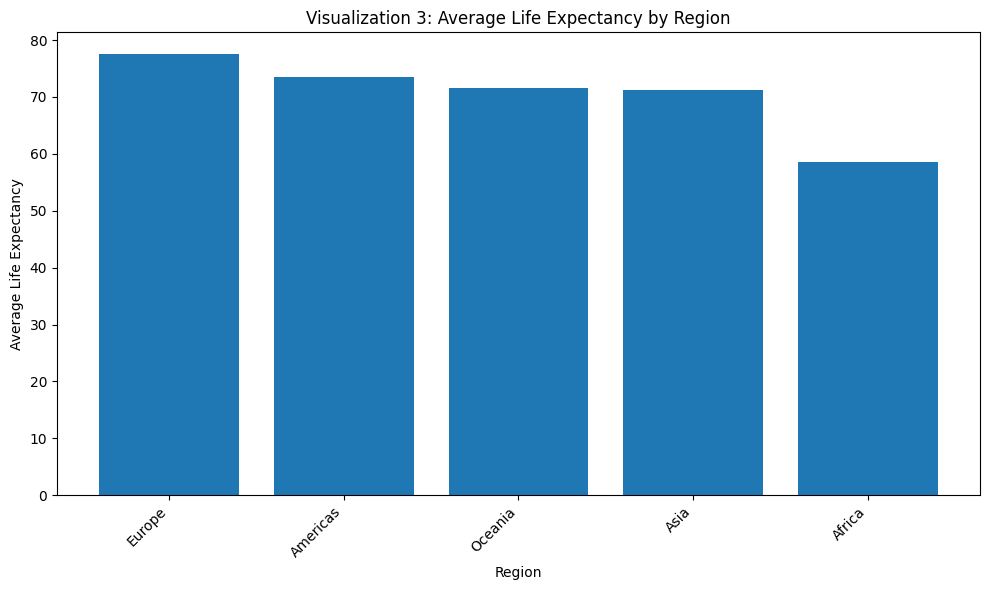

In [54]:

viz3 = (
    analysis_df.dropna(subset=["region", "life_expectancy"])
    .groupby("region", as_index=False)["life_expectancy"].mean()
    .sort_values("life_expectancy", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(viz3["region"], viz3["life_expectancy"])
plt.title("Visualization 3: Average Life Expectancy by Region")
plt.xlabel("Region")
plt.ylabel("Average Life Expectancy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## Step 13 — Visualization 4: Population density vs. life expectancy
This fourth visualization uses joined data from the life expectancy table and the REST Countries table.


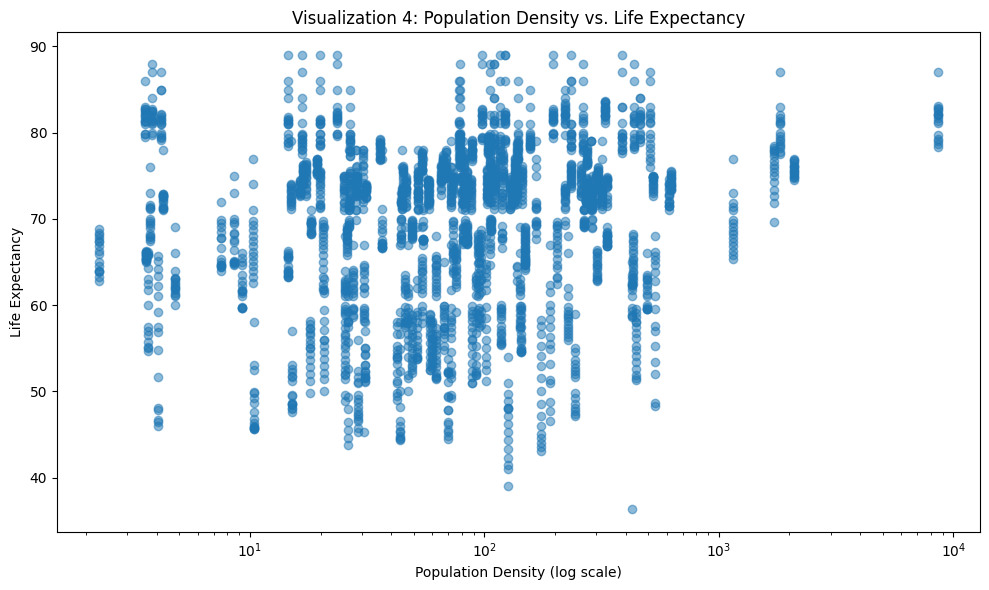

In [55]:

viz4 = analysis_df.dropna(subset=["population_density", "life_expectancy"]).copy()
viz4 = viz4[viz4["population_density"] > 0]

plt.figure(figsize=(10, 6))
plt.scatter(viz4["population_density"], viz4["life_expectancy"], alpha=0.5)
plt.xscale("log")
plt.title("Visualization 4: Population Density vs. Life Expectancy")
plt.xlabel("Population Density (log scale)")
plt.ylabel("Life Expectancy")
plt.tight_layout()
plt.show()



## Step 14 — Visualization 5: Top 15 countries by population with life expectancy labels
This fifth visualization combines the Wikipedia population table with life expectancy averages from the joined data.


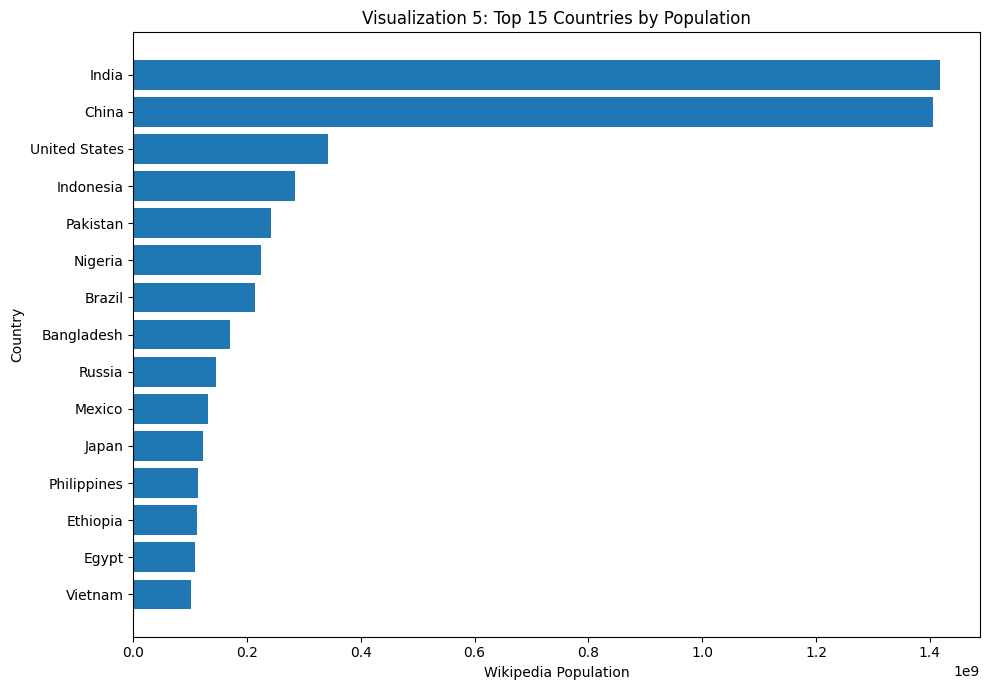

,country,avg_life_expectancy,wikipedia_population
189,Vietnam,74.77500,1.023000e+08
52,Egypt,71.50000,1.078683e+08
57,Ethiopia,59.11250,1.116530e+08
134,Philippines,67.57500,1.141236e+08
84,Japan,82.53750,1.229500e+08
108,Mexico,75.71875,1.310017e+08
139,Russia,67.76250,1.460283e+08
12,Bangladesh,69.30000,1.698289e+08
22,Brazil,73.38125,2.134210e+08
124,Nigeria,51.35625,2.238000e+08


In [56]:

country_summary = (
    analysis_df.groupby("country", as_index=False)
    .agg(
        avg_life_expectancy=("life_expectancy", "mean"),
        wikipedia_population=("wikipedia_population", "max")
    )
    .dropna(subset=["wikipedia_population"])
    .sort_values("wikipedia_population", ascending=False)
    .head(15)
)

country_summary = country_summary.sort_values("wikipedia_population", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(country_summary["country"], country_summary["wikipedia_population"])
plt.title("Visualization 5: Top 15 Countries by Population")
plt.xlabel("Wikipedia Population")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(country_summary)



## Step 15 — Print the final human-readable merged dataset
The assignment requires me to print the final transformed dataset in a human-readable form. In this step, I sort the merged data and display a readable sample at the end of the notebook.


In [57]:

final_display_df = analysis_df.sort_values(["region", "country", "year"], na_position="last").reset_index(drop=True)
print("Human-readable merged dataset preview:")
display(final_display_df.head(50))

print("Final merged dataset columns:")
print(final_display_df.columns.tolist())

print("Final merged dataset shape:", final_display_df.shape)


Human-readable merged dataset preview:


,country,iso3,year,status,region,subregion,capital,life_expectancy,gdp,life_population,wikipedia_population,population_millions,pct_of_world,area_km2,population_density,language_count,schooling,adult_mortality,hiv_aids,income_composition_of_resources
0,Algeria,DZA,2000,Developing,Africa,Northern Africa,Algiers,71.3,1757.177970,3118366.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,10.7,145.0,0.1,0.636
1,Algeria,DZA,2001,Developing,Africa,Northern Africa,Algiers,71.4,1732.857979,31592153.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,10.9,145.0,0.1,0.644
2,Algeria,DZA,2002,Developing,Africa,Northern Africa,Algiers,71.6,1774.336730,3199546.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,11.1,145.0,0.1,0.653
3,Algeria,DZA,2003,Developing,Africa,Northern Africa,Algiers,71.7,294.335560,3243514.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,11.5,146.0,0.1,0.663
4,Algeria,DZA,2004,Developing,Africa,Northern Africa,Algiers,72.3,2598.982300,3283196.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,11.7,14.0,0.1,0.673
5,Algeria,DZA,2005,Developing,Africa,Northern Africa,Algiers,72.9,31.122378,33288437.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,12.0,136.0,0.1,0.680
6,Algeria,DZA,2006,Developing,Africa,Northern Africa,Algiers,73.4,3464.617900,33777915.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,12.3,132.0,0.1,0.686
7,Algeria,DZA,2007,Developing,Africa,Northern Africa,Algiers,73.8,3935.183343,34376.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,12.3,129.0,0.1,0.690
8,Algeria,DZA,2008,Developing,Africa,Northern Africa,Algiers,74.1,495.254866,3486715.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,12.6,126.0,0.1,0.697
9,Algeria,DZA,2009,Developing,Africa,Northern Africa,Algiers,74.4,3868.831230,3546576.0,47400000.0,47.400,0.60,2381741.0,19.901408,NaN,13.1,123.0,0.1,0.705


Final merged dataset columns:
['country', 'iso3', 'year', 'status', 'region', 'subregion', 'capital', 'life_expectancy', 'gdp', 'life_population', 'wikipedia_population', 'population_millions', 'pct_of_world', 'area_km2', 'population_density', 'language_count', 'schooling', 'adult_mortality', 'hiv_aids', 'income_composition_of_resources']
Final merged dataset shape: (2938, 20)



## Step 16 — What I learned (250–500 words)
In this milestone,The lesson for this milestone is that it is not easy to merge multiple real-world datasets into a data frame, especially when each data set represents countries in very different ways, and populations are defined and measured very differently in each of the data sets. Also the accuracy of the population values can differ depending on who did the measurements and when. Each data set has been handled in a very different way. The life expectancy data frame contains annual values with some health and economic indicators. The Wikipedia population table and the data in the REST Countries API are much more up-to-date and represent data frames of countries. So some decision had to be made as to which variables to keep from the life expectancy data frame as annual variables, and which to treat as country variables.
I have spent a bit of time recently thinking about database design for my data project. Often the temptation is to just throw everything into one table. I had all my documentation for the different datasets already, so I created a new SQLite table for each of them, and then double checked that my joins were correct. This made it very easy to merge the datasets that I wanted to look at. It has really driven home the importance of good naming conventions, and also the importance of using the same country names, and bridge fields like ISO3.
This was my first time in the visualization stage, and learned that even after all the data cleaning, there is more than one way to show data. I combined the data for this stage to be able to show trends in life expectancy over time at different levels of GDP, as well as for individual countries and regions and to compare the different population subsets. As many people have mentioned, correlation does not imply causation! A country with a high GDP and high life expectancy does not necessarily mean that the GDP caused the life expectancy.
Data preparation is the most time consuming part of data analysis. This week has been spent mainly cleaning, joining, documenting and validating the data before finally doing some proper visualisation work. In retrospect, the work done so far has been of equal importance.


## Step 17 — Ethical implications
### What changes were made to the data?
In this project, I standardized headers into snake_case, cleaned and aligned country names across all three datasets, converted date and numeric columns into analysis-ready formats, removed duplicates, filtered out impossible negative numeric values, created derived columns such as population density and population in millions, and joined the sources together using country names and ISO3 codes.

### Are there any legal or regulatory guidelines for my data or project topic?
The data I used is public, aggregated, and country-level, so it does not contain personally identifiable information. That means privacy regulations such as HIPAA or GDPR are not the central legal issue here. However, I still need to respect source credibility, terms of use, proper attribution, and honest representation of what the data can and cannot support.

### What risks could be created based on the transformations done?
The biggest risks come from standardizing country names and joining datasets that were not originally built together. If two names are matched incorrectly, the final dataset could assign the wrong region, population, or country code to a record. Another risk is that country-level current population values may be compared with year-level historical health records, which can create time-mismatch bias.

### Did I make any assumptions in cleaning or transforming the data?
Yes. I assumed that standardized country names like "United States" and "United States of America" referred to the same country. I also assumed that ISO3 was an appropriate bridge when the API and life expectancy tables could be linked through country names. I treated the Wikipedia and API country-level values as contextual reference data rather than exact year-by-year matches.

### How was my data sourced and verified for credibility?
I used widely recognized public sources: the life expectancy file from the earlier milestone dataset, the Wikipedia population table, and the REST Countries API. I verified credibility by checking the structure of the tables, reviewing missingness, validating joins, and documenting my transformations so the process is reproducible.

### Was my data acquired in an ethical way?
Yes. The project used publicly accessible, non-personal data and did not involve scraping private information, bypassing permissions, or collecting any individual-level records.

### How would I mitigate the ethical implications I identified?
I would mitigate these risks by documenting every transformation, keeping source tables separate before joining, using transparent name-mapping rules, clearly labeling fields that came from different sources, and stating that the analysis is exploratory. I would also avoid overstating causal conclusions and would recommend validating results with more official year-matched population and macroeconomic sources in a future version of the project.


In [58]:

# Optional cleanup step: commit and close the database connection after the work is done.
conn.commit()
conn.close()
print("Milestone 5 notebook completed successfully.")


Milestone 5 notebook completed successfully.
